# Notebook 2: Credit Spread Decomposition

## Objective

Credit spreads (OAS) reflect more than just the probability of default. A corporate bond spread contains at least three 
distinct components. First of all, the **Expected Loss Component**, which is the compensation for expected default losses driven by PD and LGD. Secondly, the **Risk Premium Component**, compensate investors for bearing credit risk uncertainty correlated with broader market risk appetite. And also the **Liquidity Premium**, a compensation for the relative illiquidity of corporate bonds vs Treasuries.

In this notebook, we aim to analyze which component is driving spread movements among investigation period. A spread widening driven by deteriorating credit fundamentals has very different implications from one driven purely by a risk-off sentiment shock.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.regression.rolling import RollingOLS
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load main dataset
df = pd.read_csv('../data/processed/main_dataset.csv',
                 index_col='date',
                 parse_dates=True)

## Descriptive Statistics

Before decomposing spreads, we examine their statistical properties across rating buckets. Key metrics include central tendency, dispersion, and distribution shape (skewness and kurtosis).

In [24]:
oas_cols = ['aaa_oas', 'ig_oas', 'bbb_oas', 'hy_oas']

# Summary statistics
desc = df[oas_cols].describe().round(2)
desc.loc['skew'] = df[oas_cols].skew().round(2)
desc.loc['kurt'] = df[oas_cols].kurt().round(2)

print("Descriptive Statistics (bps):")
print(desc)

Descriptive Statistics (bps):
       aaa_oas   ig_oas  bbb_oas   hy_oas
count  1326.00  1326.00  1326.00  1326.00
mean     46.25   107.14   133.00   357.95
std      11.92    26.00    31.53    72.55
min      27.00    73.00    93.00   259.00
25%      36.00    86.00   108.00   305.00
50%      45.00    96.00   119.00   328.50
75%      56.00   129.00   159.00   409.75
max      82.00   171.00   210.00   599.00
skew      0.53     0.65     0.69     0.81
kurt     -0.74    -0.87    -0.84    -0.32


As shown, the average OAS levels increase consistently as credit quality deteriorates, reflecting higher required compensation for default and liquidity risk. Lower-rated credit spreads exhibit substantially higher volatility, suggesting stronger sensitivity to market stress and macroeconomic uncertainty. 

In addition, all four rating buckets show positive skewness (AAA: 0.53, IG: 0.65, BBB: 0.69, HY: 0.81), indicating that spread widening episodes tend to occur abruptly during stress periods. Kurtosis is negative across all spread buckets (ranging from -0.74 to -0.32), indicating relatively flat distributions compared with a normal distribution. This pattern may reflect regime-dependent spread behavior, where spreads cluster around different market environments (e.g., tight risk-on regimes versus wider stress regimes), rather than remaining concentrated around a single stable mean.

## Spread Distribution

We visualize the full distribution of each rating bucket to complement the summary statistics. The histogram shows the frequency of each spread level over the sample period, with mean and median marked for reference.

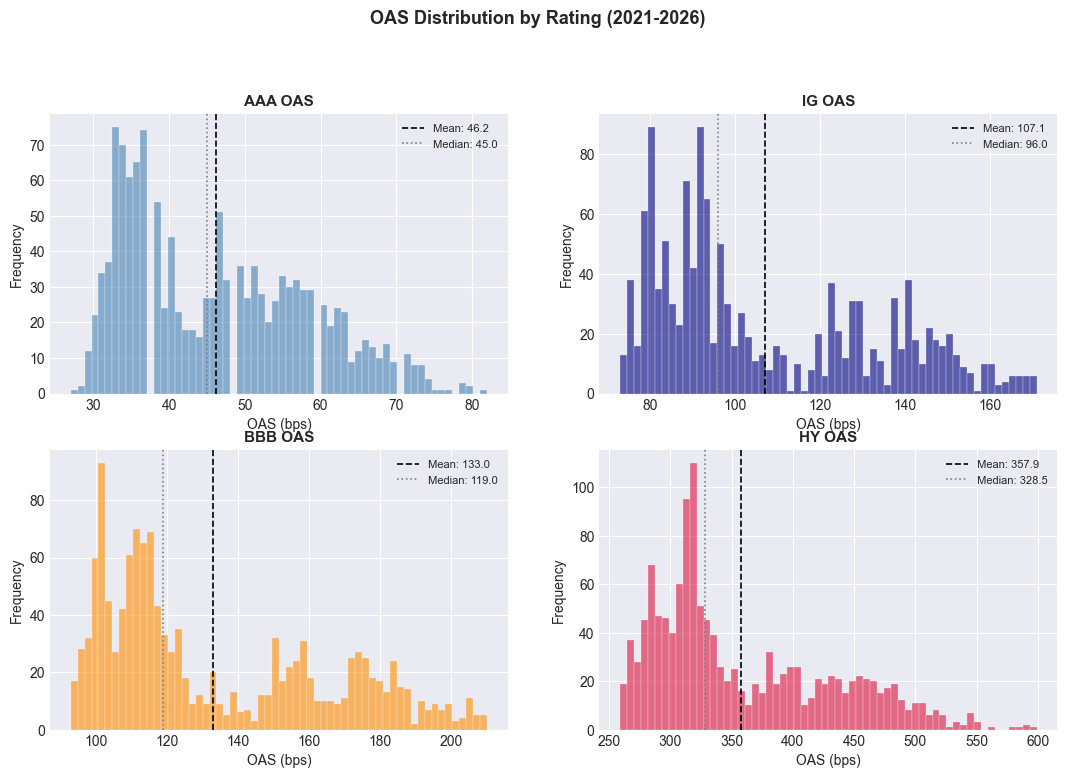

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

colors = ['steelblue', 'navy', 'darkorange', 'crimson']
labels = ['AAA OAS', 'IG OAS', 'BBB OAS', 'HY OAS']

for i, (col, color, label) in enumerate(zip(oas_cols, colors, labels)):
    ax = axes[i]
    
    # Histogram
    ax.hist(df[col], bins=60, color=color, alpha=0.6, edgecolor='white', linewidth=0.3)
    
    # Mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='gray', linestyle=':', linewidth=1.2, label=f'Median: {median_val:.1f}')
    
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('OAS (bps)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('OAS Distribution by Rating (2021-2026)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../data/processed/02_oas_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

All four distributions display a visually bimodal shape, with spreads clustering around two broad market environments. This regime-dependent structure is broadly consistent with the relatively flat (platykurtic) distributions observed earlier. Two distinct clusters are visible in each rating bucket, broadly corresponding to tighter spread regimes (2021 and parts of 2024–2026) and wider spread regimes observed during the 2022 tightening cycle and subsequent stress episodes.

The mean exceeds the median in all four buckets, confirming the positive skewness noted earlier. The gap between mean and median widens as credit quality deteriorates, indicating that stress episodes pull the mean disproportionately higher in lower-rated credits.

HY OAS shows the most pronounced right tail, extending to nearly 600 bps, reflecting the severe spread widening observed during the 2022 tightening cycle and later trade-related stress episodes.

## Spread Term Structure

Raw OAS levels capture the total compensation demanded by investors for holding corporate bonds. To isolate specific dimensions of credit risk, we construct four derived spreads:

**IG - AAA**: measures the additional spread compensation required beyond the highest-quality corporate bonds, serving as a proxy for broad investment-grade credit premium；
**BBB - AAA**: the credit risk gradient within the investment-grade universe, measuring how much extra spread the lowest IG rating commands over the highest;
**HY - IG**: measures the additional compensation required to move from investment-grade into speculative-grade credit risk;
**BBB - IG**: measures lower-tier investment-grade spread pressure relative to the broader IG market.

In [26]:
df['ig_aaa_spread'] = df['ig_oas'] - df['aaa_oas']
df['bbb_aaa_spread'] = df['bbb_oas'] - df['aaa_oas']
df['hy_ig_spread'] = df['hy_oas'] - df['ig_oas']
df['bbb_ig_spread'] = df['bbb_oas'] - df['ig_oas']

derived_cols = ['ig_aaa_spread', 'bbb_aaa_spread', 'hy_ig_spread', 'bbb_ig_spread']

print("Derived spread statistics (bps):")
print(df[derived_cols].describe().round(2))

Derived spread statistics (bps):
       ig_aaa_spread  bbb_aaa_spread  hy_ig_spread  bbb_ig_spread
count        1326.00         1326.00       1326.00        1326.00
mean           60.89           86.75        250.81          25.87
std            16.73           22.16         47.98           5.68
min            39.00           60.00        178.00          19.00
25%            47.00           68.00        216.00          21.00
50%            55.00           78.00        233.00          23.00
75%            75.00          105.00        281.00          30.00
max           104.00          142.00        432.00          41.00


The HY−IG spread dominates in magnitude, averaging 251 bps with a range of 178 to 432 bps. This confirms that the transition from investment-grade to speculative-grade credit represents the largest discrete repricing step across the rating spectrum.

The BBB−AAA spread, with a mean of 87 bps, is substantially wider than the IG−AAA spread (mean = 61 bps), indicating that lower-tier investment-grade credit contributes materially to overall IG spread behavior. This observation is broadly consistent with the large representation of BBB-rated bonds within the modern investment-grade universe.

The BBB−IG spread exhibits the narrowest range in the sample (19 to 41 bps, std = 6 bps), suggesting that the relative pricing of BBB credit within the IG universe remains more stable than absolute spread levels across broader market regimes.

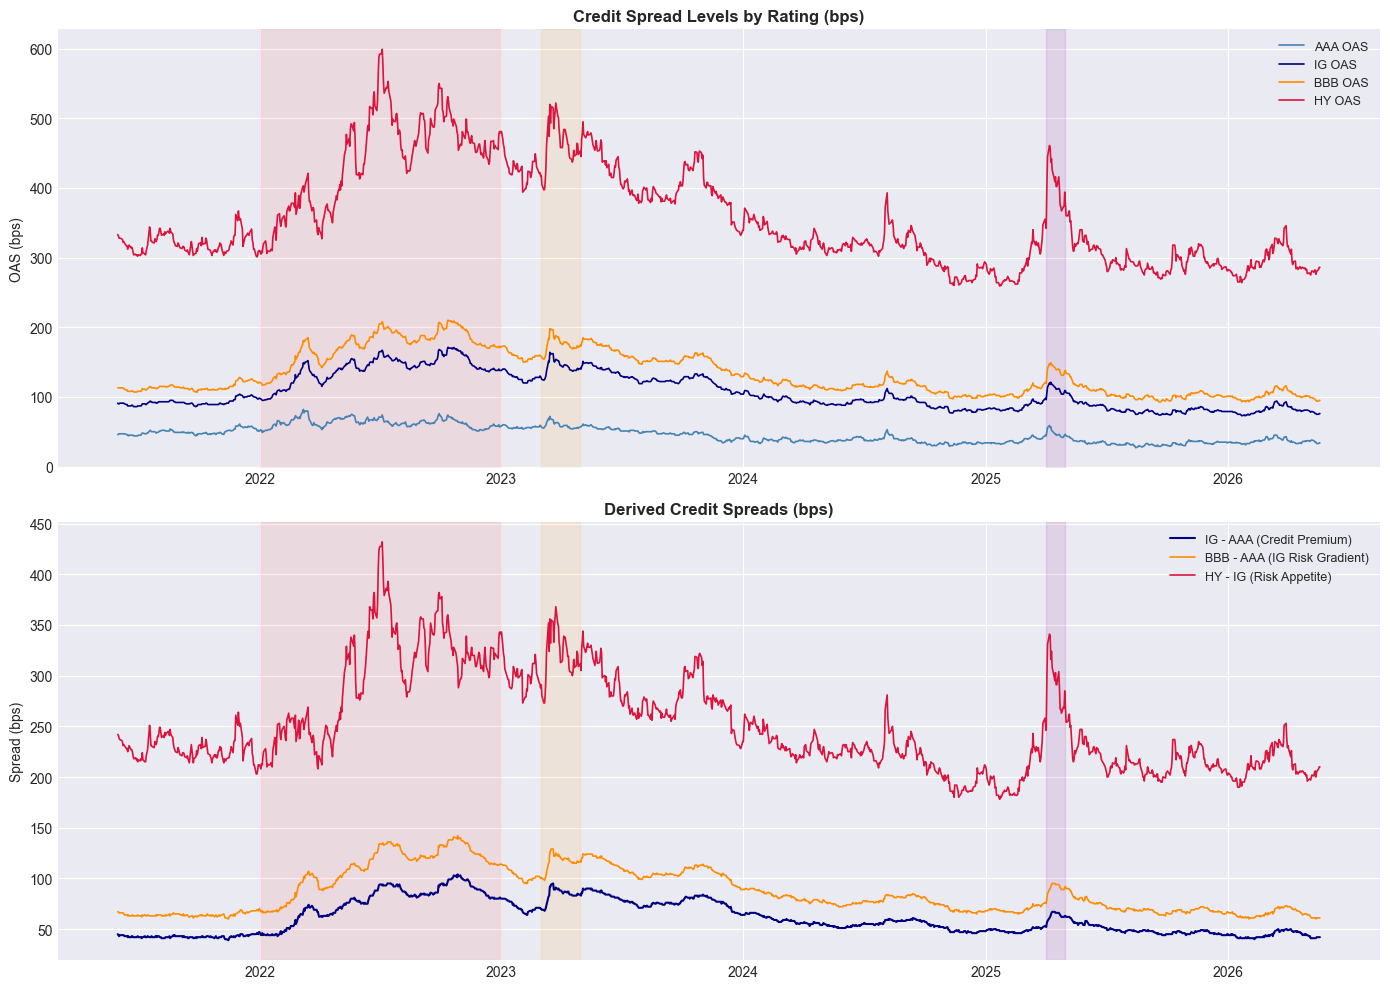

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Raw OAS levels
ax1 = axes[0]
colors = ['steelblue', 'navy', 'darkorange', 'crimson']
labels = ['AAA OAS', 'IG OAS', 'BBB OAS', 'HY OAS']

for col, color, label in zip(oas_cols, colors, labels):
    ax1.plot(df.index, df[col], color=color, label=label, linewidth=1.2)

ax1.set_title('Credit Spread Levels by Rating (bps)', fontsize=12, fontweight='bold')
ax1.set_ylabel('OAS (bps)')
ax1.legend(loc='upper right', fontsize=9)

# Plot 2: Derived spreads
ax2 = axes[1]
derived_info = {
    'ig_aaa_spread':  ('IG - AAA (Credit Premium)',  'navy',       1.5),
    'bbb_aaa_spread': ('BBB - AAA (IG Risk Gradient)','darkorange', 1.2),
    'hy_ig_spread':   ('HY - IG (Risk Appetite)',     'crimson',    1.2),
}

for col, (label, color, lw) in derived_info.items():
    ax2.plot(df.index, df[col], color=color, label=label, linewidth=lw)

# Shade key events
for ax in axes:
    ax.axvspan('2022-01-01', '2022-12-31', alpha=0.07, color='red')
    ax.axvspan('2023-03-01', '2023-04-30', alpha=0.10, color='orange')
    ax.axvspan('2025-04-01', '2025-05-01', alpha=0.10, color='purple')

ax2.set_title('Derived Credit Spreads (bps)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Spread (bps)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/02_spread_termstructure.png', dpi=150, bbox_inches='tight')
plt.show()

By plotting both raw OAS levels and derived spreads, we are able to distinguish between periods where the entire credit spectrum shifts in parallel (systemic stress) and periods where spread differentials widen across rating buckets (selective credit deterioration).

During the 2022 rate hike cycle, all rating buckets widened substantially in parallel, with HY OAS reaching nearly 600 bps and BBB OAS approaching 210 bps. The broad widening across the full rating spectrum is consistent with a systemic, macro-driven stress regime rather than isolated idiosyncratic credit deterioration.

The SVB stress event in March 2023 produced a sharp but relatively short-lived spike, most visible in HY OAS and the HY−IG derived spread. The rapid normalization suggests that broader contagion concerns eased relatively quickly following policy intervention and market stabilization.

The 2025 tariff-related shock generated a similarly acute but brief dislocation, with HY−IG widening sharply before retracing within approximately one month. The relatively fast retracement in both the SVB and tariff-related episodes contrasts with the prolonged widening observed during 2022, suggesting shorter-lived stress dynamics relative to the sustained tightening cycle.

BBB−IG is excluded from the main visualization due to its comparatively narrow range (19 to 41 bps) relative to others. This narrow range suggests that spread differentiation within the IG universe remains modest relative to the much larger repricing observed at the IG-to-HY boundary.

## Correlation Analysis

Correlation analysis examines how credit spreads co-move with market risk indicators and whether these relationships remain stable across different market regimes.

We evaluate correlations across three distinct time windows:

1. **Full sample (2021-2026)** captures the average relationship over the entire period;
2. **Pre June 2023 (Tightening & Stress Regime)** covers from the zero-rate baseline into the aggressive Fed tightening cycle, including the 2022 spread widening and the March 2023 SVB stress episode;
3. **Post June 2023 (Normalization & Repricing Regime)** covers the subsequent stabilization period characterized by spread normalization, soft-landing expectations, and later tariff-related volatility.

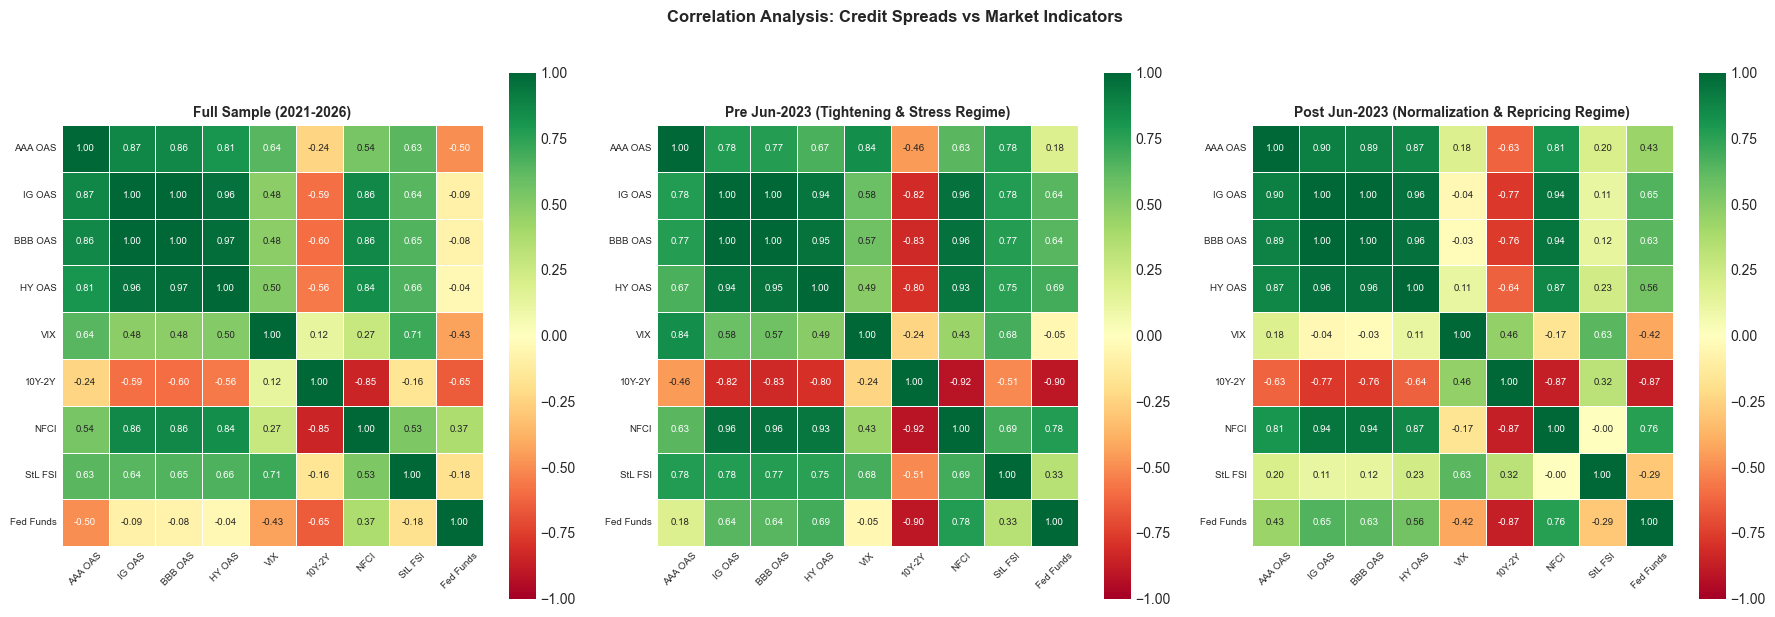

In [28]:
corr_cols = ['aaa_oas', 'ig_oas', 'bbb_oas', 'hy_oas', 'vix', 't10y2y', 'nfci', 'stlfsi', 'fedfunds']

# Rename for cleaner heatmap labels
label_map = {
    'aaa_oas':  'AAA OAS',
    'ig_oas':   'IG OAS',
    'bbb_oas':  'BBB OAS',
    'hy_oas':   'HY OAS',
    'vix':      'VIX',
    't10y2y':   '10Y-2Y',
    'nfci':     'NFCI',
    'stlfsi':   'StL FSI',
    'fedfunds': 'Fed Funds',
}

mid_date = '2023-06-01'

# Full sample correlation
corr_full = (df[corr_cols].rename(columns=label_map).corr().round(2))

# Two sub-periods
corr_pre  = df.loc[:mid_date, corr_cols].rename(columns=label_map).corr().round(2)
corr_post = df.loc[mid_date:, corr_cols].rename(columns=label_map).corr().round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, corr_mat, title in zip(
    axes,
    [corr_full, corr_pre, corr_post],
    ['Full Sample (2021-2026)',
     'Pre Jun-2023 (Tightening & Stress Regime)',
     'Post Jun-2023 (Normalization & Repricing Regime)']
):
    sns.heatmap(
        corr_mat,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        annot_kws={'size': 7}
    )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Correlation Analysis: Credit Spreads vs Market Indicators',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Within-spread correlations (left-up corner) remain consistently high across all three windows (e.g., IG–BBB: 0.97–1.00), confirming that credit rating buckets largely move in tandem under both stress and normalization regimes. However, AAA OAS exhibits somewhat lower correlation with IG and BBB during the tightening period (0.77–0.78), suggesting partial decoupling of top-tier credit from broader investment-grade spread dynamics during the aggressive hiking cycle.

VIX–spread relationships display a clear regime dependence. During the tightening and stress regime, VIX shows relatively strong correlation with all spread buckets, particularly AAA OAS (0.84). In the post-2023 normalization regime, these correlations weaken substantially, indicating that equity volatility became a less dominant driver of credit spread movements outside major systemic stress periods.

The 10Y–2Y slope maintains a persistently negative relationship with credit spreads across both sub-periods. This suggests that yield curve steepening or normalization is generally associated with spread compression and improving risk sentiment.

Among all macro indicators, NFCI exhibits the most stable and consistently high correlation with credit spreads across regimes (generally above 0.85), highlighting the strong connection between financial conditions and corporate credit pricing.

Overall, the substantial variation in correlation structures across regimes suggests that static linear relationships may be insufficient to fully capture credit spread dynamics, motivating the regime-dependent framework developed later in the analysis.

## OAS Decomposition via OLS Regression

To quantify the drivers of OAS movements to observable market risk factors, we estimate the following OLS regression:

$$OAS_t = \alpha + \beta_1 \cdot VIX_t + \beta_2 \cdot T10Y2Y_t + \beta_3 \cdot NFCI_t + \varepsilon_t$$

The estimated factor sensitivities are interpreted as follows:
- **$\beta_1 \cdot VIX$**: risk premium component, captures the portion of spread driven by broad market risk aversion and equity volatility;
- **$\beta_2 \cdot T10Y2Y$**: macro/rate environment component, captures the influence of yield curve shape and rate cycle positioning on credit spreads;
- **$\beta_3 \cdot NFCI$**: financial conditions component, captures the contribution of overall financial system tightness to spread levels;
- **$\varepsilon$**: residual component, representing spread variation not captured by the selected macro and market risk factors.

**Federal Funds Rate:** The federal funds rate is excluded from the regression based on three main considerations. First, the fed funds rate is highly correlated with NFCI across both sub-periods (0.76–0.78), introducing multicollinearity that destabilizes coefficient estimates. Second, NFCI is a composite financial conditions index of which the policy rate is a constituent, creating substantial informational overlap. Third, the fed funds rate in our dataset is a monthly average forward-filled to daily frequency, introducing artificial smoothness that can bias standard errors in a daily regression. NFCI is therefore treated as the primary proxy for broad financial conditions and monetary policy transmission effects.

We run **two versions of the regression**:

- Raw OLS: factors in their original units, used to decompose OAS into bps-scale components for visualization；
- Standardized OLS: independent variables standardized to zero mean and unit variance, while OAS remains in bps. This allows direct comparison of relative factor importance (each standardized beta represents the bps change in OAS associated with a one standard deviation move in the factor).


  AAA OAS
  R-squared:      0.5624
  Adj R-squared:  0.5614
  Observations:    1326

  Factor         Raw Coef    Std Coef (bps/SD)    p-value
  -------------------------------------------------------
  const            45.503               46.250     0.0000 ***
  vix               1.042                5.483     0.0000 ***
  t10y2y            4.026                2.387     0.0000 ***
  nfci             48.223                6.975     0.0000 ***

  IG OAS
  R-squared:      0.8117
  Adj R-squared:  0.8113
  Observations:    1326

  Factor         Raw Coef    Std Coef (bps/SD)    p-value
  -------------------------------------------------------
  const           161.609              107.137     0.0000 ***
  vix               0.932                4.906     0.0000 ***
  t10y2y           10.206                6.050     0.0000 ***
  nfci            180.150               26.058     0.0000 ***

  BBB OAS
  R-squared:      0.8242
  Adj R-squared:  0.8238
  Observations:    1326

  Factor       

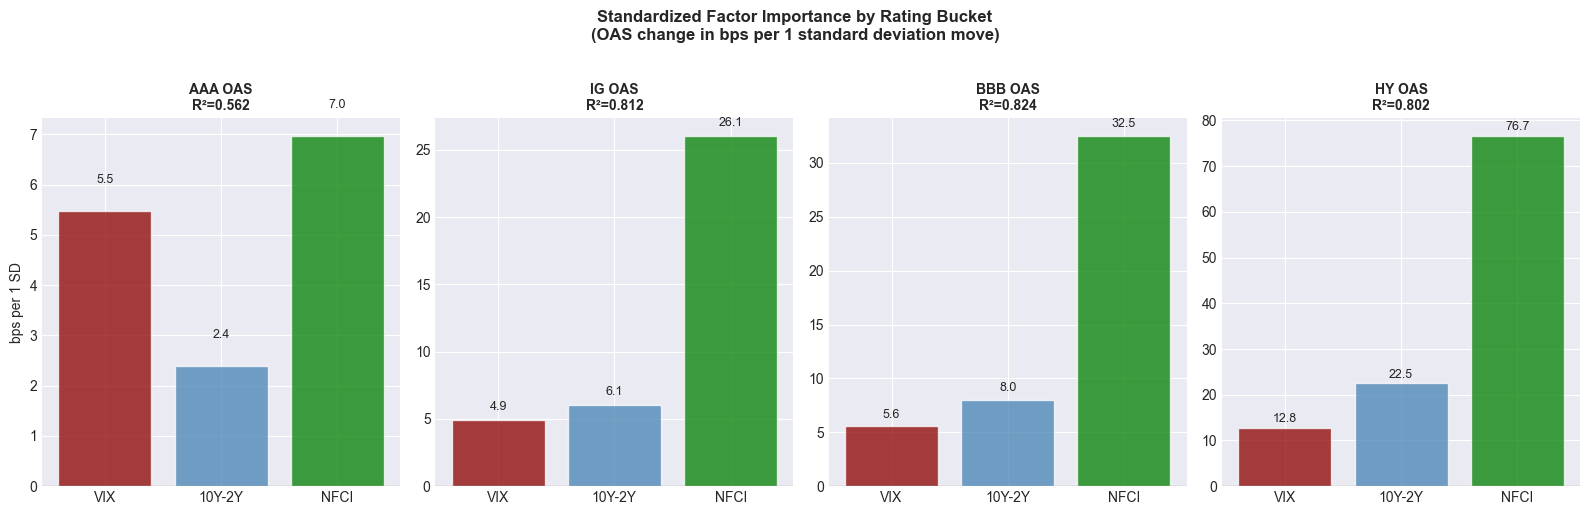

In [ ]:
oas_cols = ['aaa_oas', 'ig_oas', 'bbb_oas', 'hy_oas']
factors  = ['vix', 't10y2y', 'nfci']

# Raw OLS
raw_results    = {}
decomposed     = pd.DataFrame(index=df.index)

for col in oas_cols:
    y = df[col]
    X = sm.add_constant(df[factors])
    model = sm.OLS(y, X).fit()
    raw_results[col] = model

    # Store bps-scale components
    decomposed[f'{col}_vix_component']   = (
        model.params['vix'] * df['vix']
    )
    decomposed[f'{col}_macro_component'] = (
        model.params['t10y2y'] * df['t10y2y']
    )
    decomposed[f'{col}_nfci_component']  = (
        model.params['nfci'] * df['nfci']
    )
    decomposed[f'{col}_residual'] = model.resid
    decomposed[f'{col}_fitted'] = model.fittedvalues

# Standardized OLS
scaler = StandardScaler()
df_std = df.copy()
df_std[factors] = scaler.fit_transform(df[factors])

std_results = {}

for col in oas_cols:
    y = df[col]
    X = sm.add_constant(df_std[factors])
    model = sm.OLS(y, X).fit()
    std_results[col] = model

# Print results
labels_map = {
    'aaa_oas': 'AAA OAS',
    'ig_oas':  'IG OAS',
    'bbb_oas': 'BBB OAS',
    'hy_oas':  'HY OAS'
}

for col in oas_cols:
    raw = raw_results[col]
    std = std_results[col]

    print(f"\n{'='*60}")
    print(f"  {labels_map[col]}")
    print(f"{'='*60}")
    print(f"  R-squared:      {raw.rsquared:.4f}")
    print(f"  Adj R-squared:  {raw.rsquared_adj:.4f}")
    print(f"  Observations:    {int(model.nobs)}")
    print(f"\n  {'Factor':<12} {'Raw Coef':>10} "
          f"{'Std Coef (bps/SD)':>20} {'p-value':>10}")
    print(f"  {'-'*55}")

    raw_const = raw.params['const']
    std_const = std.params['const']
    pval_const = raw.pvalues['const']
    sig = ('***' if pval_const < 0.01 else
           '**'  if pval_const < 0.05 else
           '*'   if pval_const < 0.1  else '')
    print(f"  {'const':<12} {raw_const:>10.3f} "
          f"{std_const:>20.3f} {pval_const:>10.4f} {sig}")

    for factor in factors:
        raw_coef = raw.params[factor]
        std_coef = std.params[factor]
        pval     = raw.pvalues[factor]
        sig = ('***' if pval < 0.01 else
               '**'  if pval < 0.05 else
               '*'   if pval < 0.1  else '')
        print(f"  {factor:<12} {raw_coef:>10.3f} "
              f"{std_coef:>20.3f} {pval:>10.4f} {sig}")

# Standardized beta bar chart
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors_factors = ['darkred', 'steelblue', 'green']
factor_labels  = ['VIX', '10Y-2Y', 'NFCI']

for ax, col in zip(axes, oas_cols):
    std = std_results[col]
    betas = [std.params[f] for f in factors]

    bars = ax.bar(
        factor_labels, betas,
        color=colors_factors,
        alpha=0.75,
        edgecolor='white'
    )

    for bar, beta in zip(bars, betas):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{beta:.1f}',
            ha='center', va='bottom', fontsize=9
        )

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{labels_map[col]}\nR²={std.rsquared:.3f}',fontsize=10, fontweight='bold')
    ax.set_ylabel('bps per 1 SD' if col == 'aaa_oas' else '')

plt.suptitle(
    'Standardized Factor Importance by Rating Bucket\n'
    '(OAS change in bps per 1 standard deviation move)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/02_standardized_betas.png',
            dpi=150, bbox_inches='tight')
plt.show()

All three factors are statistically significant at the 1% level across all four rating buckets, confirming that equity volatility, yield curve shape, and financial 
conditions are systematic drivers of corporate credit spreads throughout the sample period.

**Model fit** improves substantially from AAA ($R^2 =0.56$) to IG, BBB, and HY ($R^2=0.80–0.82$). The relatively lower R-squared for AAA suggests that top-tier credit spreads retain a larger idiosyncratic component not captured by broad market risk factors, while IG, BBB, and HY spreads exhibit substantially stronger dependence on systematic macro and market conditions.

The **large intercept** terms suggest that a meaningful portion of average spread levels is not fully explained by the selected time-varying macro factors, potentially reflecting persistent structural characteristics of corporate credit spreads.

**NFCI is the dominant factor across all rating buckets** based on standardized coefficients. A one standard deviation tightening in financial conditions is associated with spread widening of 7.0 bps (AAA), 26.1 bps (IG), 32.5 bps (BBB), and 76.7 bps (HY). The amplification effect across the rating spectrum is substantial, a given financial conditions shock widens HY spreads approximately eleven times more than AAA spreads, consistent with the flight-to-quality dynamic often observed during stress episodes.

**VIX sensitivity** is relatively stable within the IG universe but increases sharply for HY (12.8 bps/SD), indicating that equity volatility has a broadly similar effect on investment-grade credit pricing but a significantly amplified effect on high yield, consistent with the higher equity-like sensitivity of speculative grade bonds.

**The 10Y-2Y slope** contributes 2.4 bps/SD for AAA, 6.1 bps/SD for IG, 8.0 bps/SD for BBB, and 22.5 bps/SD for HY. Given that the steeper cirve associated with wider spreads, the positive direction reflects the sample composition, where yield curve steepening was concentrated in the 2022 tightening cycle when spreads were simultaneously widening. This sign is likely regime-dependent, motivating the rolling analysis in the following studies.

Overall, NFCI is the most influential factor across all rating buckets based on standardized coefficients, while the relative importance of VIX and the yield curve slope varies across credit quality segments.

Next, we will use the stacked area chart to show how the relative contribution of each component evolves over time.

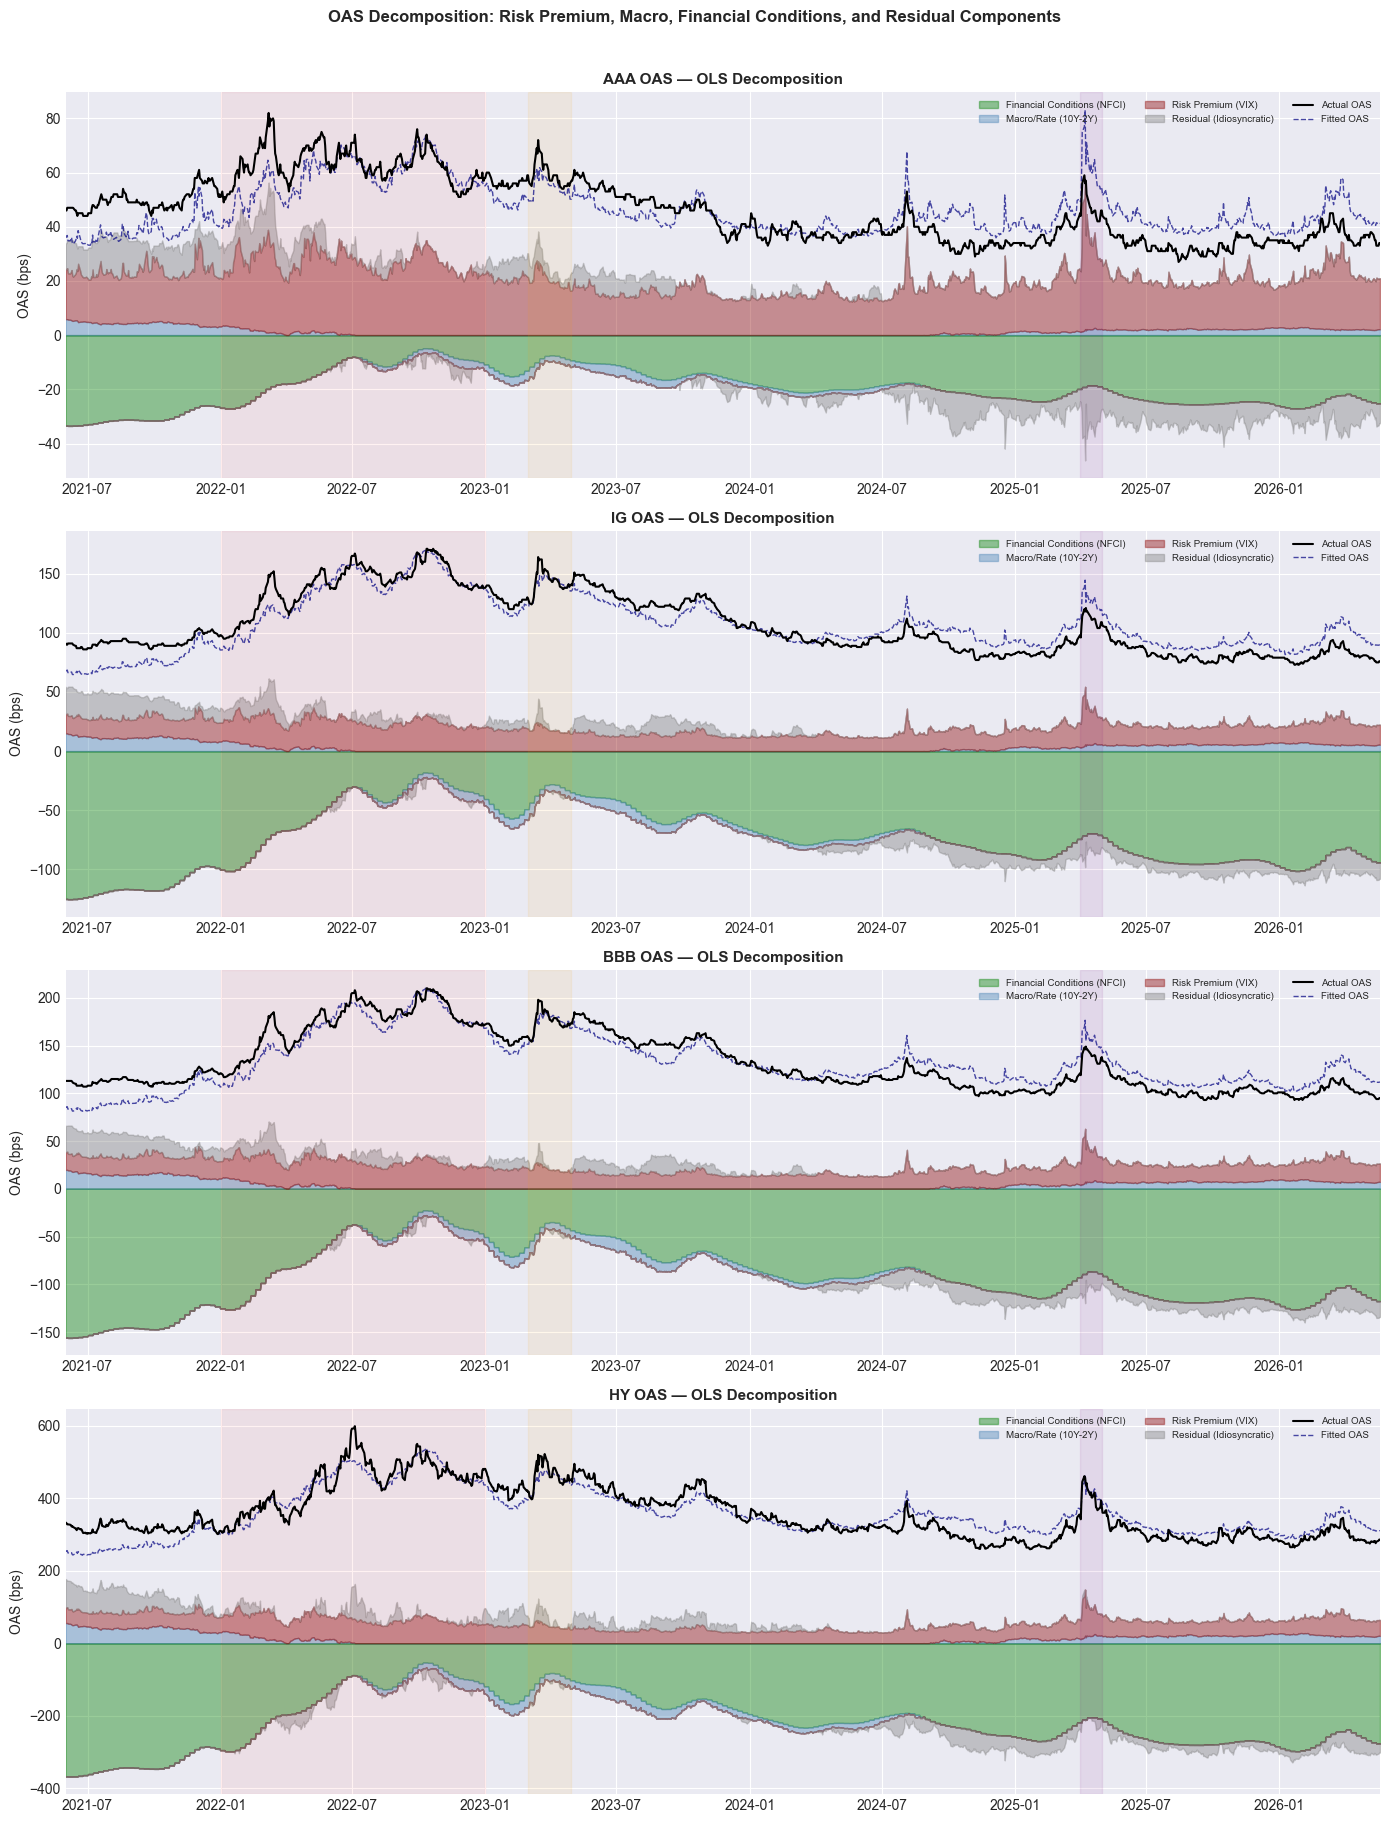

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(14, 18))

component_info = {
    'nfci_component':  ('Financial Conditions (NFCI)', 'green'),
    'macro_component': ('Macro/Rate (10Y-2Y)',          'steelblue'),
    'vix_component':   ('Risk Premium (VIX)',            'darkred'),
    'residual':        ('Residual (Idiosyncratic)',      'gray'),
}

labels_map = {
    'aaa_oas': 'AAA OAS',
    'ig_oas':  'IG OAS',
    'bbb_oas': 'BBB OAS',
    'hy_oas':  'HY OAS',
}

for ax, col in zip(axes, oas_cols):
    
    # Stack components
    pos_bottom = np.zeros(len(df))
    neg_bottom = np.zeros(len(df))
    
    for comp, (label, color) in component_info.items():
        values = decomposed[f'{col}_{comp}'].values
        
        # Separate positive and negative contributions
        pos_vals = np.where(values > 0, values, 0)
        neg_vals = np.where(values < 0, values, 0)
        
        ax.fill_between(df.index,
                        pos_bottom, pos_bottom + pos_vals,
                        alpha=0.4, color=color, label=label)
        ax.fill_between(df.index,
                        neg_bottom, neg_bottom + neg_vals,
                        alpha=0.4, color=color)
        
        pos_bottom += pos_vals
        neg_bottom += neg_vals
    
    # Actual OAS
    ax.plot(df.index, df[col],
            color='black', linewidth=1.5,
            label='Actual OAS', zorder=5)
    
    # Fitted OAS
    ax.plot(df.index, decomposed[f'{col}_fitted'],
            color='navy', linewidth=1.0,
            linestyle='--', label='Fitted OAS',
            alpha=0.7, zorder=4)
    
    # Shade events periods
    ax.axvspan('2022-01-01', '2022-12-31', alpha=0.05, color='red')
    ax.axvspan('2023-03-01', '2023-04-30', alpha=0.08, color='orange')
    ax.axvspan('2025-04-01', '2025-05-01', alpha=0.08, color='purple')
    
    ax.set_title(f'{labels_map[col]} — OLS Decomposition', fontsize=11, fontweight='bold')
    ax.set_ylabel('OAS (bps)')
    ax.set_xlim(df.index.min(), df.index.max())
    ax.legend(loc='upper right', fontsize=7, ncol=3)

plt.suptitle(
    'OAS Decomposition: Risk Premium, Macro, '
    'Financial Conditions, and Residual Components',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../data/processed/02_oas_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

As shown, the decomposition confirms that financial conditions (NFCI component, green) is the dominant driver of OAS variation across all rating buckets, consistent with the standardized regression results before. The NFCI component accounts for the largest share of fitted spread movements throughout the sample.

Negative component values are economically meaningful. During 2021 and much of 2024-2026, the NFCI and macro components appear below zero, reflecting periods of accommodative financial conditions and a steep or normalizing yield curve associated with lower spread levels relative to their long-run average. The actual OAS during these periods was low precisely because these factors were contributing negatively.

During the 2022 rate hike cycle, the NFCI component turns sharply positive across all rating buckets, becoming the primary driver of spread widening. The VIX component also rises during this period, though its contribution is visually smaller relative to NFCI, consistent with the standardized betas we derived before.

The residual component (gray) is notably large for AAA OAS throughout the sample, consistent with the lower R-squared of 0.56 observed in the regression. For IG, BBB, and HY, the residual is smaller and more stable, indicating that systematic factors contribute a larger share of spread variation in lower-rated credits.

The SVB stress episode (March 2023) and the 2025 tariff shock both appear as brief spikes in the residual component, particularly visible in AAA and HY OAS. This suggests that these events generated short-lived market dislocations not fully captured by the three systematic macro factors, consistent with their event-driven rather than macro-driven nature.

Model fit (dashed blue line vs black line) is visually strong for IG, BBB, and HY throughout the sample, with the fitted values tracking actual OAS closely through the major stress episodes observed in the sample. AAA fit is weaker, particularly during 2021-2022, where the model systematically underestimates actual AAA spread levels.

## Rolling OLS — Factor Sensitivity Over Time

The full-sample OLS assumes a static linear relationship between credit spreads and risk factors across the full sample. But the correlation analysis section already demonstrated that this assumption is violated, whereas correlations between spreads and market indicators shifted substantially between the tightening and normalization regimes.

Rolling OLS addresses this by re-estimating the regression coefficients within a moving window, allowing us to observe how factor sensitivities evolve across different market environments.

We use a 126-day rolling window (approximately 6 months) as a balance between **stability** (sufficient observations for reliable coefficient estimation) and **responsiveness** (short enough to capture regime transitions within the sample).

The standardized factors from section above are used directly, so rolling betas remain comparable across time in units of bps per 1 standard deviation move. A rising beta indicates increasing sensitivity to that factor; a falling or sign-reversing beta indicates a structural shift in the spread-factor relationship.

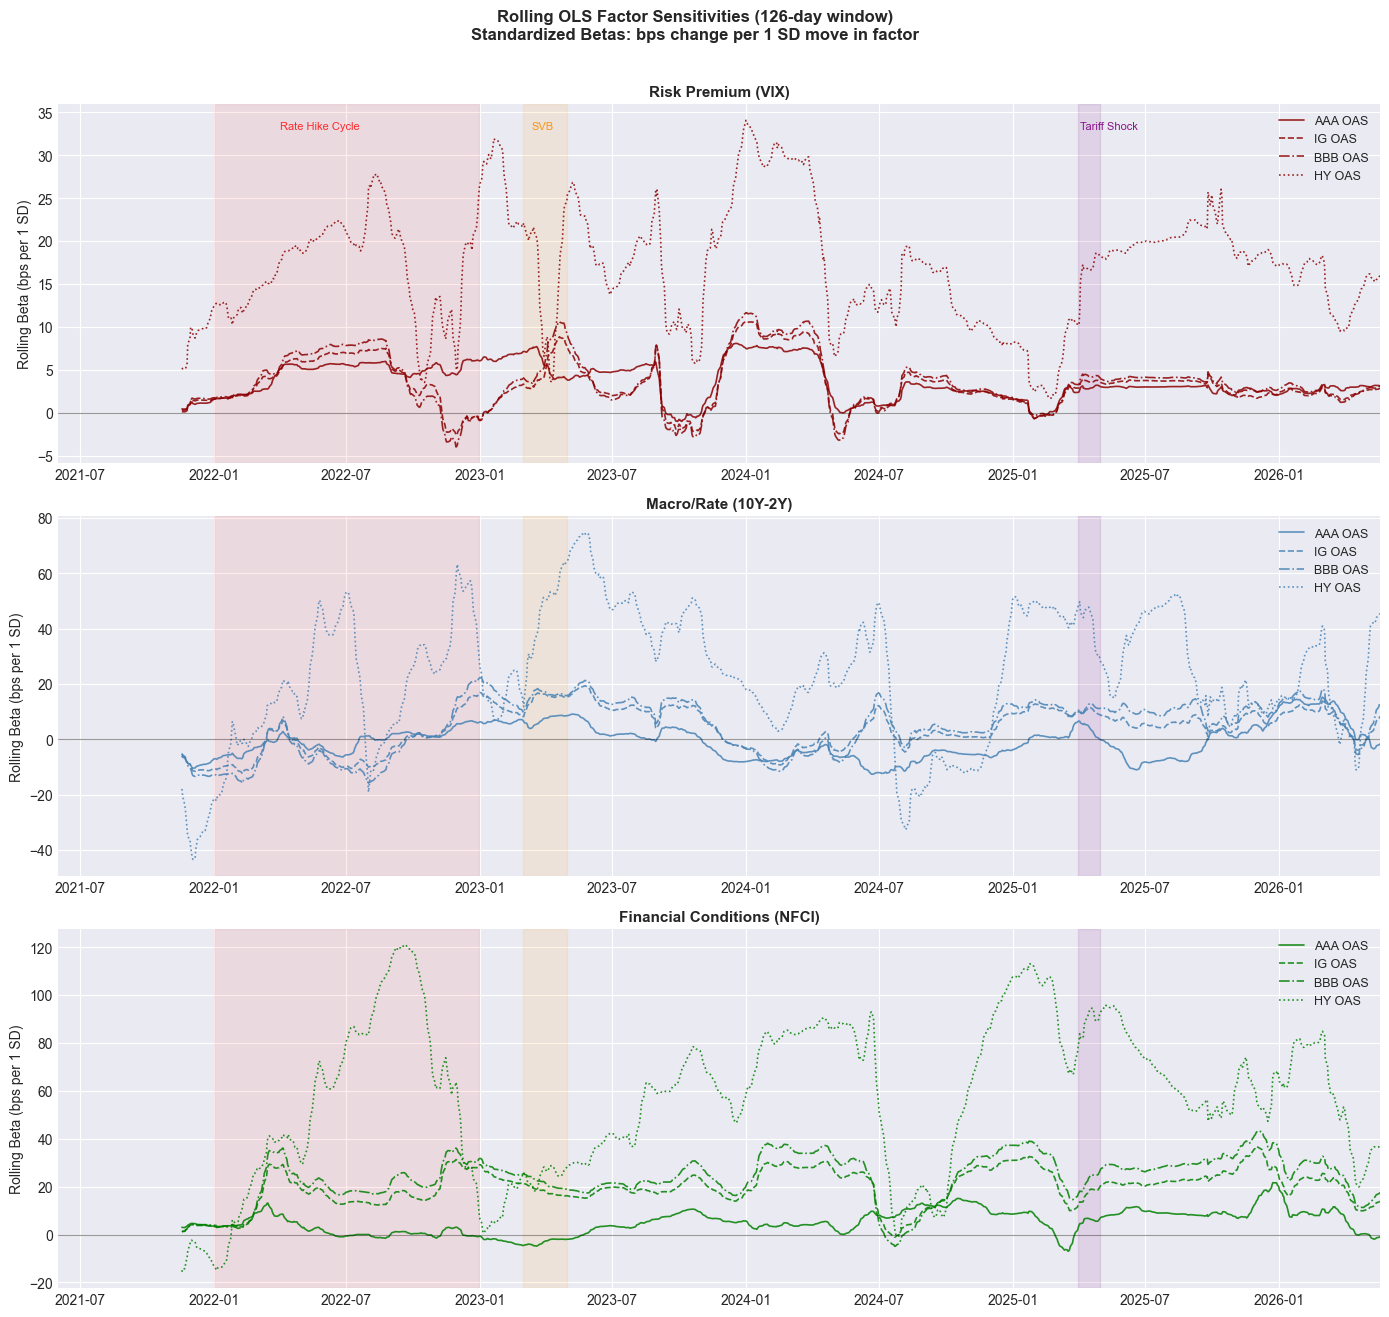

In [34]:
from statsmodels.regression.rolling import RollingOLS

WINDOW = 126
factors = ['vix', 't10y2y', 'nfci']
factor_labels = {
    'vix':    ('Risk Premium (VIX)',         'darkred'),
    't10y2y': ('Macro/Rate (10Y-2Y)',        'steelblue'),
    'nfci':   ('Financial Conditions (NFCI)','green'),
}
labels_map = {
    'aaa_oas': 'AAA OAS',
    'ig_oas':  'IG OAS',
    'bbb_oas': 'BBB OAS',
    'hy_oas':  'HY OAS',
}
line_styles = ['-', '--', '-.', ':']

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

for ax, (factor, (f_label, f_color)) in zip(
    axes, factor_labels.items()
):
    for col, ls in zip(oas_cols, line_styles):
        y = df[col]
        X = sm.add_constant(df_std[factors])

        rolling_model = RollingOLS(
            y, X, window=WINDOW
        ).fit()
        beta = rolling_model.params[factor]

        ax.plot(df.index, beta,
                color=f_color,
                linestyle=ls,
                linewidth=1.2,
                label=labels_map[col],
                alpha=0.85)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)

    ax.axvspan('2022-01-01', '2022-12-31', alpha=0.07, color='red')
    ax.axvspan('2023-03-01', '2023-04-30', alpha=0.10, color='orange')
    ax.axvspan('2025-04-01', '2025-05-01', alpha=0.10, color='purple')

    ax.set_title(f_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Rolling Beta (bps per 1 SD)')
    ax.set_xlim(df.index.min(), df.index.max())
    ax.legend(loc='upper right', fontsize=9)

# Add event annotations on top panel
ymax = axes[0].get_ylim()[1]
axes[0].text(pd.Timestamp('2022-04-01'), ymax * 0.92,
             'Rate Hike Cycle',
             fontsize=8, color='red', alpha=0.8)
axes[0].text(pd.Timestamp('2023-03-13'), ymax * 0.92,
             'SVB',
             fontsize=8, color='darkorange', alpha=0.9)
axes[0].text(pd.Timestamp('2025-04-03'), ymax * 0.92,
             'Tariff Shock',
             fontsize=8, color='purple', alpha=0.9)

plt.suptitle(
    f'Rolling OLS Factor Sensitivities ({WINDOW}-day window)\n'
    f'Standardized Betas: bps change per 1 SD move in factor',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../data/processed/02_rolling_betas.png', dpi=150, bbox_inches='tight')
plt.show()

Rolling-window regressions reveal that factor sensitivities are highly state-dependent and vary substantially across market regimes, violating the static OLS assumption of constant coefficients. The instability is most pronounced during periods of macro tightening and systemic stress, where both the magnitude and direction of factor exposures change materially over time.

**VIX sensitivity** is low and relatively stable during the initial low-volatility environment of 2021, rises meaningfully throughout the 2022 rate hike cycle, and spikes sharply around the SVB stress event in March 2023. The increase is particularly pronounced for HY OAS, where the rolling beta reaches approximately 30 bps per 1 standard deviation move in VIX. Sensitivity then compresses and stabilizes during most of 2024, before rising again during the 2025 tariff shock. The persistent separation between HY and the investment grade buckets confirms that speculative-grade credit is structurally more sensitive to equity volatility across all market environments. This is consistent with the equity-like behavior of high-yield credit, where deteriorating firm value and rising default probability strengthen the linkage between credit spreads and equity market volatility.

**10Y-2Y Slope Sensitivity** exhibits significant sign instability over time. Betas are negative during early 2022, consistent with the standard interpretation that curve flattening reflects tightening financial conditions and recession risk. However, the relationship turns sharply positive around the SVB episode and remains predominantly positive through much of 2023-2026. This instability explains the counterintuitive positive coefficient observed in the full-sample OLS regression and suggests that the macro interpretation of curve steepening is itself regime-dependent. HY OAS again displays the highest beta volatility, with rolling sensitivities fluctuating between approximately -40 and +75 bps per standard deviation move.

**NFCI sensitivity** is consistently positive throughout the sample and dominates in magnitude, confirming its role as the primary systematic driver of credit spreads. Sensitivity rises sharply during the 2022 tightening cycle, with HY beta peaking near 120 bps/SD — substantially above the static full-sample estimate of approximately 77 bps/SD. This divergence highlights the extent to which static OLS understates risk sensitivity during stress regimes. NFCI sensitivity compresses materially after 2023, consistent with the normalization of financial conditions during the soft-landing environment, before rising again during the 2025 tariff shock.

Taken together, the rolling analysis demonstrates that credit spread dynamics cannot be adequately characterized by a single linear relationship over the full sample. Factor sensitivities vary not only in magnitude, but also in sign, persistence, and cross-sectional dispersion across market regimes.

The results suggest the existence of distinct underlying credit environments:

- a low-volatility risk-on regime;
- a macro-tightening regime dominated by financial conditions deterioration;
- short-lived event-driven stress regimes such as SVB and tariff shock;
- and a post-tightening normalization regime with reduced macro sensitivity.

These findings provide strong empirical support for a regime-switching framework, which will become the central focus of Notebook 3.

In [35]:
# Save decomposed components
output_path = '../data/processed/decomposed_spreads.csv'
decomposed.to_csv(output_path)

print(f"Shape: {decomposed.shape}")
print(f"\nColumns saved:")
for col in decomposed.columns: print(f"  - {col}")

Shape: (1326, 20)

Columns saved:
  - aaa_oas_vix_component
  - aaa_oas_macro_component
  - aaa_oas_nfci_component
  - aaa_oas_residual
  - aaa_oas_fitted
  - ig_oas_vix_component
  - ig_oas_macro_component
  - ig_oas_nfci_component
  - ig_oas_residual
  - ig_oas_fitted
  - bbb_oas_vix_component
  - bbb_oas_macro_component
  - bbb_oas_nfci_component
  - bbb_oas_residual
  - bbb_oas_fitted
  - hy_oas_vix_component
  - hy_oas_macro_component
  - hy_oas_nfci_component
  - hy_oas_residual
  - hy_oas_fitted
